In [2]:
import sys
sys.path.append('../')
from utils_models import *

In [19]:
max_ql = 20
max_ol = 50
system = FluxoniumOscillatorSystem(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2',
    )

tot_time = 840
tlist = np.linspace(0, tot_time, tot_time)

with open('../pickles/mesolve_wd1649_unitary_large_dim.pkl', 'rb') as file:
    results = pickle.load(file)

In [20]:
lists = []
for ql in [0,1,2,3]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(system.qbt.truncated_dim):
            if q != ql:
                for o in range(system.osc.truncated_dim):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    # print(pop_list)
    lists.append(pop_list)

with open('../pickles/mesolve_wd1649_unitary_large_dim_leakage_list.pkl', 'wb') as file:
    pickle.dump(lists, file)
    

t loop: 100%|██████████| 840/840 [01:34<00:00,  8.85it/s]


Text(0.5, 0, 't (ns)')

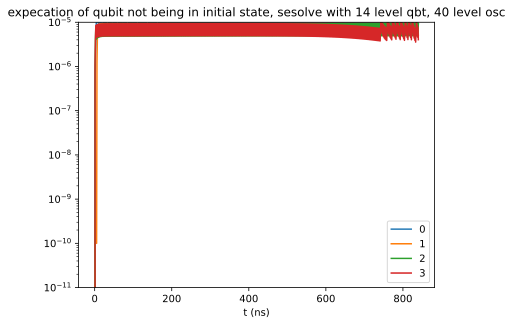

In [21]:
with open('../pickles/mesolve_wd1649_unitary_large_dim_leakage_list.pkl', 'rb') as file:
    lists = pickle.load(file)
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.ylim(1e-11,1e-5)
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 14 level qbt, 40 level osc')
plt.xlabel('t (ns)')

In [32]:
interactive_heatmap(results[2], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=839), Output(…

state 0: 0-50 lvl, 7-35 lvl          => 85 lvl

state 3: 3-45lvl, 12-25lvl          => 70 lvl

state 1: 1-20 lvl, 10-12lvl          => 32 lvl

state 2: 2-20 lvl, 9-12 lvl, 11- 12 lvl => 44 lvl  => 76 lvl

(800.0, 820.0)

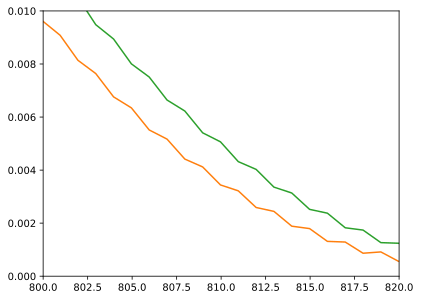

In [28]:
plt.plot(tlist,results[0].expect[1])
plt.plot(tlist,results[1].expect[1])
plt.plot(tlist,results[2].expect[1])
plt.plot(tlist,results[3].expect[1])
plt.ylim(0,0.01)
plt.xlim(800,820)

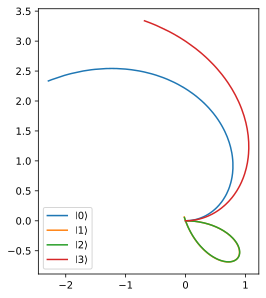

In [26]:
tlist = results[0].times
first_dominant_freq =find_dominant_frequency(results[0].expect[0],tlist)
for i, result in enumerate(results):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    plt.plot(-alpha.imag,alpha.real,label =  rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_71099/2661621938.py: 41

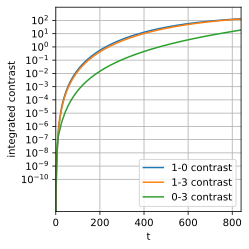

In [27]:
plt.figure(figsize=(3+3/8,3+3/8))
kappa_val = 1e-3

alpha1 = results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha0 = results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha3 = results[3].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


squared_diff = np.square(abs(alpha0-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-0 contrast')

squared_diff = np.square(abs(alpha3-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-3 contrast')


squared_diff = np.square(abs(alpha3-alpha0))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='0-3 contrast')



plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()

